Parsing Dates

In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import datetime

df = pd.read_csv('/content/database.csv')

np.random.seed()

df.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


In [6]:
print(df['Date'].head())

0    01/02/1965
1    01/04/1965
2    01/05/1965
3    01/08/1965
4    01/09/1965
Name: Date, dtype: object


In [7]:
# to check the dtype of a column
print(df['Date'].dtype)

object


In [30]:
df['parsed_date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', errors='coerce', utc=True)

print(df['parsed_date'].head())

0   1965-01-02 00:00:00+00:00
1   1965-01-04 00:00:00+00:00
2   1965-01-05 00:00:00+00:00
3   1965-01-08 00:00:00+00:00
4   1965-01-09 00:00:00+00:00
Name: parsed_date, dtype: datetime64[ns, UTC]


In [31]:
day_of_the_month_earthquake = df['parsed_date'].dt.day
day_of_the_month_earthquake.head()

,parsed_date
0,2.0
1,4.0
2,5.0
3,8.0
4,9.0


<Axes: xlabel='parsed_date', ylabel='Count'>

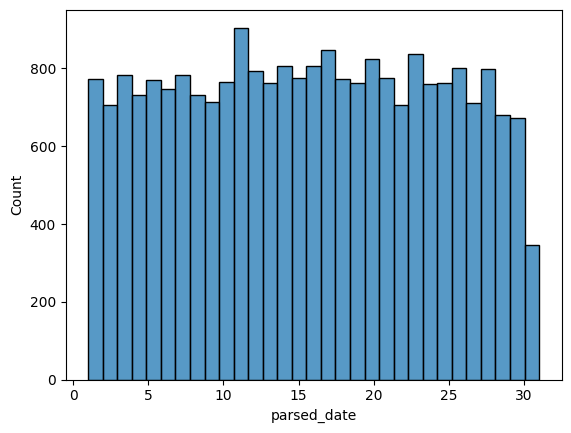

In [36]:
# Plotting a histogram
day_of_the_month_earthquake = day_of_the_month_earthquake.dropna()
sns.histplot(day_of_the_month_earthquake, kde=False, bins=31)

In [39]:
# parsing date is done.Now we will check some missing values etc
df_missing_values = df.isnull().sum()
print(df_missing_values)

Date                              3
Time                              0
Latitude                          0
Longitude                         0
Type                              0
Depth                             0
Depth Error                   18951
Depth Seismic Stations        16315
Magnitude                         0
Magnitude Type                    3
Magnitude Error               23085
Magnitude Seismic Stations    20848
Azimuthal Gap                 16113
Horizontal Distance           21808
Horizontal Error              22256
Root Mean Square               6060
ID                                0
Source                            0
Location Source                   0
Magnitude Source                  0
Status                            0
parsed_date                       3
dtype: int64


In [53]:
# replacing the missng values

df = pd.read_csv('/content/database.csv')

cleaning_rules = {
    'date': pd.to_datetime('1970-01-01'),
    'Depth Error': 0.0,
    'Depth Seismic Stations': 0,
    'Magnitude Type': 'Unknown',
    'Magnitude Error': 0.0,
    'Magnitude Seismic Stations': 0,
    'Azimuthal Gap': 0.0,
    'Horizontal Distance': 0.0,
    'Horizontal Error': 0.0,
    'Root Mean Square': 0.0
}
df.fillna(value=cleaning_rules, inplace=True)
df.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,0.0,0.0,6.0,MW,...,0.0,0.0,0.0,0.0,0.0,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,0.0,0.0,5.8,MW,...,0.0,0.0,0.0,0.0,0.0,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,0.0,0.0,6.2,MW,...,0.0,0.0,0.0,0.0,0.0,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,0.0,0.0,5.8,MW,...,0.0,0.0,0.0,0.0,0.0,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,0.0,0.0,5.8,MW,...,0.0,0.0,0.0,0.0,0.0,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic
